<a href="https://colab.research.google.com/github/tasosquantumcomputing/Machine-Learning/blob/main/MultiplePolynomialRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Libraries



In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing the dataset

In [18]:
df = pd.read_csv("auto-mpg.csv")

Checking for missing values

In [19]:
(df == "?").sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [20]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


Deleting Missing Values

In [21]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = df['horsepower'].astype(float)

# Αφαίρεση missing
df = df.dropna()

Checking if Polynomial Regression is valid for our data

In [22]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


Checking non linearites using scatter plots

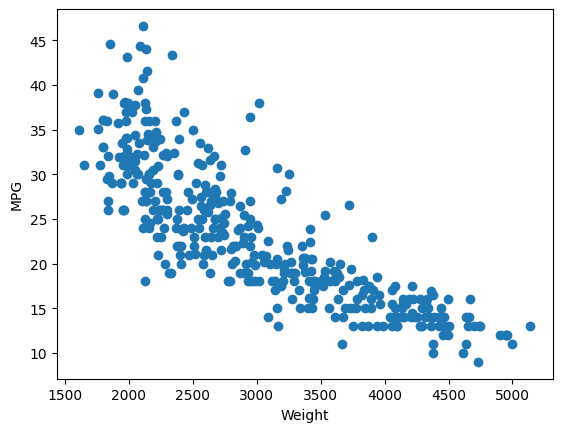

In [23]:
plt.scatter(df['weight'], df['mpg'])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

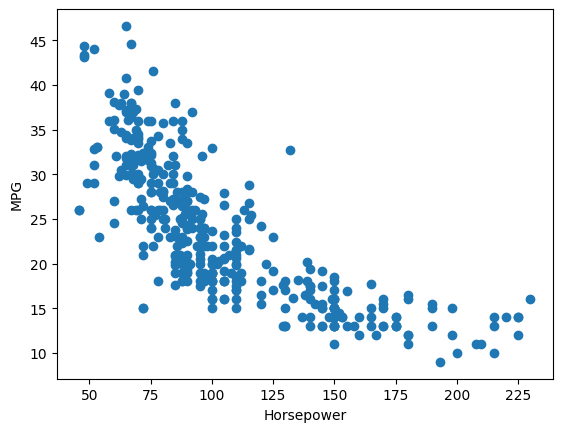

In [24]:
plt.scatter(df['horsepower'], df['mpg'])
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

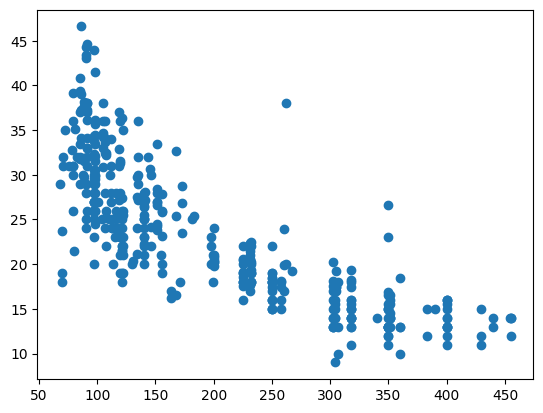

In [25]:
plt.scatter(df['displacement'], df['mpg'])
plt.show()

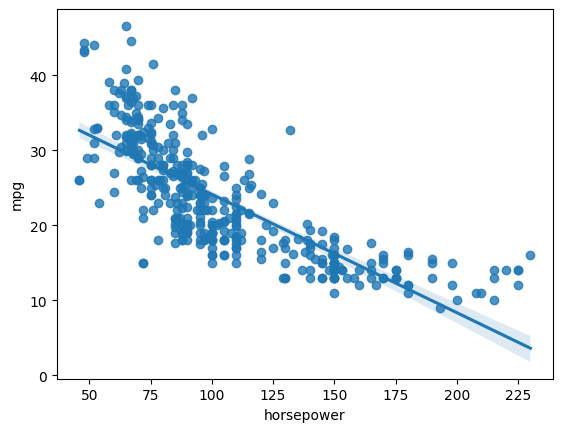

In [26]:
sns.regplot(x='horsepower', y='mpg', data=df)
plt.show()

Residual Pattern Test

In [27]:
from sklearn.linear_model import LinearRegression

X = df[['horsepower']]
y = df['mpg']

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)
residuals = y - pred

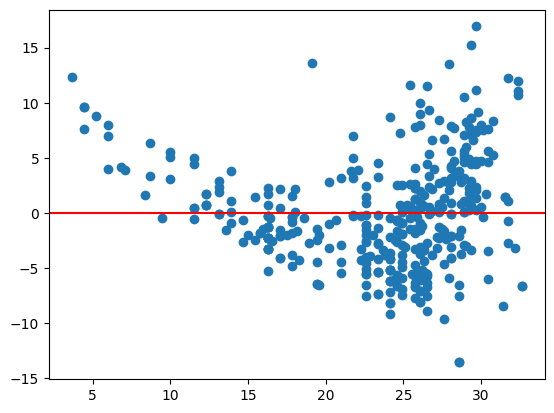

In [28]:
plt.scatter(pred, residuals)
plt.axhline(0, color='red')
plt.show()

Residuals doent have Pattern so Linear Regression is a good fitting model

Correlation Check

In [30]:
df.corr(numeric_only=True)['mpg'].sort_values()

,mpg
weight,-0.832244
displacement,-0.805127
horsepower,-0.778427
cylinders,-0.777618
acceleration,0.423329
origin,0.565209
model year,0.580541
mpg,1.000000


Now we will use Polynomial Regression

In [31]:
features = ['cylinders', 'displacement', 'horsepower',
            'weight', 'acceleration', 'model year']

X = df[features]
y = df['mpg']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

poly_model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()), ('linear', LinearRegression())])

In [40]:
from sklearn.metrics import r2_score, mean_squared_error

y_train_pred = poly_model.predict(X_train)
y_test_pred = poly_model.predict(X_test)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Train R2: 0.8901932667618386
Test R2: 0.8546282648766312
Test MSE: 7.419858147287966


if train R^2 >> test R^2 we have overfitting

In [41]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_test_linear = linear_model.predict(X_test)

print("Linear Test R2:", r2_score(y_test, y_test_linear))

Linear Test R2: 0.7942349075428586


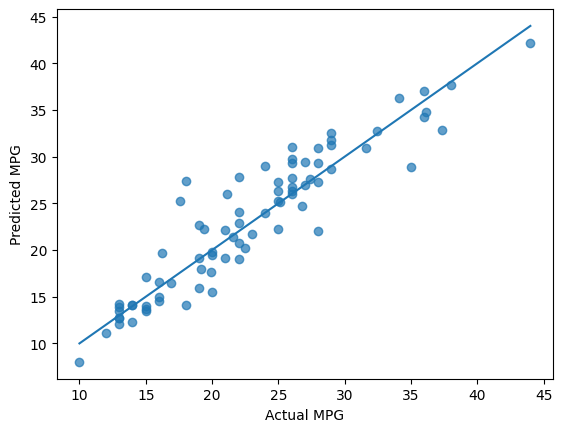

In [42]:
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()